In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ex1

In [38]:
#open data
with open("/home/hungday/Documents/python/Data-visualization-/Data_EX1.txt",'r') as f:
    lines = f.readlines() 
lines=lines[1:]
for i in range(len(lines)):
    lines[i]=lines[i].split()[1:]
for i in range(len(lines)):
    for j in range(len(lines[i])):
        lines[i][j]=float(lines[i][j])
lines=lines[:-6]


In [39]:
df = pd.DataFrame(lines)
df.replace({-99: None, 99: None}, inplace=True)
df = df.apply(pd.to_numeric, errors='coerce')

In [40]:
all_day=[[None]*3 for i in range(len(lines)*len(lines[0]))]
for i in range(len(lines[0])):
    for j in range(len(lines)):
        if i < 9 and j<9:
            all_day[i*len(lines)+j][0]='2009-0{month}-0{day}'.format(month=i+1,day=j+1)
        elif i< 9 and j >=9:
            all_day[i*len(lines)+j][0]='2009-0{month}-{day}'.format(month=i+1,day=j+1)
        elif i>=9 and j<9:
            all_day[i*len(lines)+j][0]='2009-{month}-0{day}'.format(month=i+1,day=j+1)
        elif i>=9 and j>=9:
            all_day[i*len(lines)+j][0]='2009-{month}-{day}'.format(month=i+1,day=j+1)
        all_day[i*len(lines)+j][1] = '00:00:00'
        if lines[j][i]==-99 or lines[j][i] == 99:
            all_day[i*len(lines)+j][2]=None
        else:
            all_day[i*len(lines)+j][2]=lines[j][i]
all_day_df=pd.DataFrame(all_day)
all_day_df

,0,1,2
0,2009-01-01,00:00:00,15.0
1,2009-01-02,00:00:00,14.3
2,2009-01-03,00:00:00,13.2
3,2009-01-04,00:00:00,15.4
4,2009-01-05,00:00:00,18.0
...,...,...,...
367,2009-12-27,00:00:00,15.0
368,2009-12-28,00:00:00,16.4
369,2009-12-29,00:00:00,18.0
370,2009-12-30,00:00:00,18.0


In [41]:

for i in range(len(all_day_df)):
    if all_day_df[0][i] == '2009-02-30' or all_day_df[0][i] == '2009-02-31' or all_day_df[0][i] == '2009-04-31' or all_day_df[0][i] == '2009-06-31' or all_day_df[0][i] == '2009-09-31' or all_day_df[0][i] == '2009-11-31':
        all_day_df = all_day_df.drop(i)
all_day_df

,0,1,2
0,2009-01-01,00:00:00,15.0
1,2009-01-02,00:00:00,14.3
2,2009-01-03,00:00:00,13.2
3,2009-01-04,00:00:00,15.4
4,2009-01-05,00:00:00,18.0
...,...,...,...
367,2009-12-27,00:00:00,15.0
368,2009-12-28,00:00:00,16.4
369,2009-12-29,00:00:00,18.0
370,2009-12-30,00:00:00,18.0


In [42]:
all_day_list=all_day_df[[0,2]].values.tolist()
all_day_list

[['2009-01-01', 15.0],
 ['2009-01-02', 14.3],
 ['2009-01-03', 13.2],
 ['2009-01-04', 15.4],
 ['2009-01-05', 18.0],
 ['2009-01-06', 19.4],
 ['2009-01-07', 15.4],
 ['2009-01-08', 12.0],
 ['2009-01-09', 10.2],
 ['2009-01-10', 7.6],
 ['2009-01-11', 10.0],
 ['2009-01-12', 11.5],
 ['2009-01-13', 10.1],
 ['2009-01-14', 11.7],
 ['2009-01-15', 9.4],
 ['2009-01-16', 12.8],
 ['2009-01-17', 15.9],
 ['2009-01-18', 16.3],
 ['2009-01-19', 17.3],
 ['2009-01-20', 19.4],
 ['2009-01-21', 16.9],
 ['2009-01-22', 17.7],
 ['2009-01-23', 12.8],
 ['2009-01-24', 10.3],
 ['2009-01-25', 13.0],
 ['2009-01-26', 11.5],
 ['2009-01-27', 13.6],
 ['2009-01-28', 15.0],
 ['2009-01-29', 15.2],
 ['2009-01-30', 13.2],
 ['2009-01-31', 15.4],
 ['2009-02-01', 18.0],
 ['2009-02-02', 17.6],
 ['2009-02-03', 18.1],
 ['2009-02-04', 19.8],
 ['2009-02-05', 17.5],
 ['2009-02-06', 15.9],
 ['2009-02-07', 17.5],
 ['2009-02-08', 16.7],
 ['2009-02-09', 15.6],
 ['2009-02-10', 16.4],
 ['2009-02-11', 18.7],
 ['2009-02-12', 19.2],
 ['2009-02-13

In [43]:
data=np.array(lines)
data[data == 99] = np.nan
data[data == -99] = np.nan
# Calculate monthly means, ignoring NaNs
monthly_means = np.nanmean(data, axis=0)

# Calculate annual mean
annual_mean = np.nanmean(monthly_means)
monthly_min = np.nanmin(data, axis=0)
monthly_max = np.nanmax(data, axis=0)
overall_min = np.nanmin(monthly_min)
overall_max = np.nanmax(monthly_max)
min_month = np.argmin(monthly_min)
max_month = np.argmax(monthly_max)

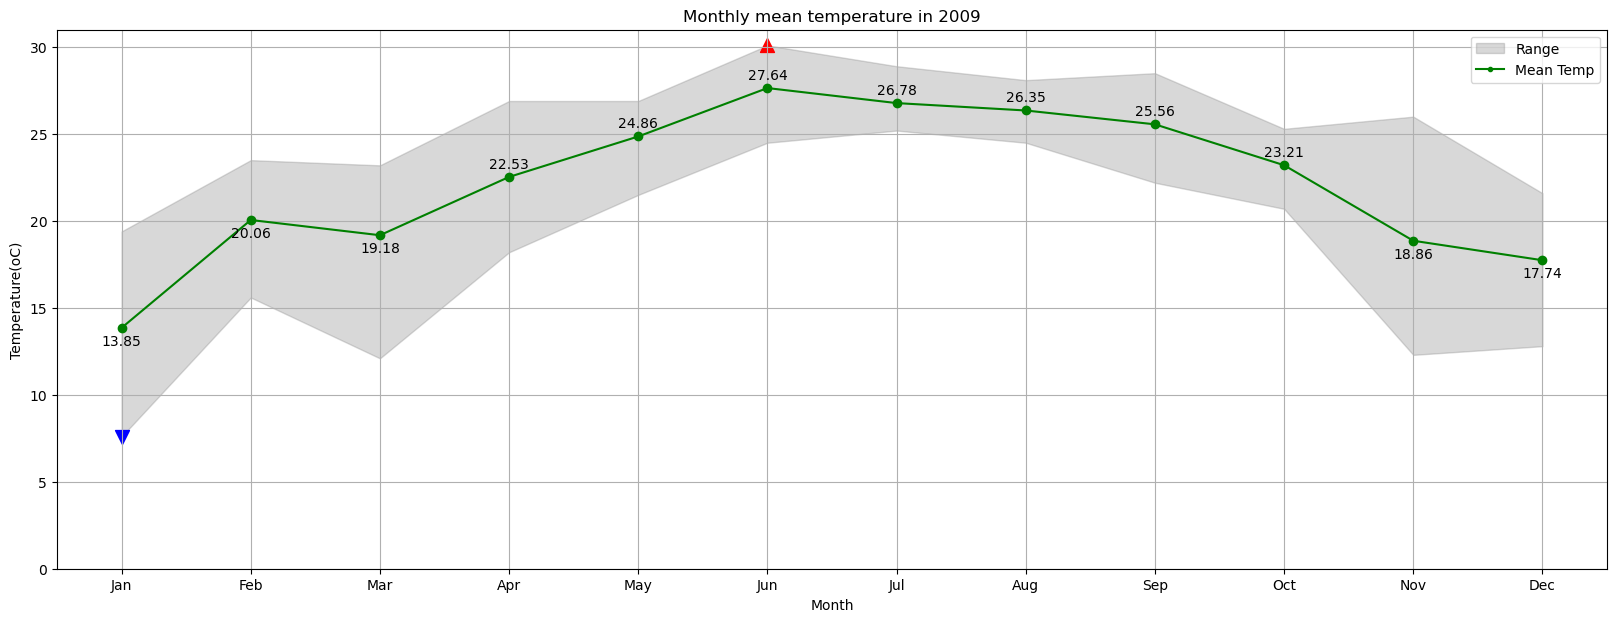

In [44]:
import math
all_days_list_copy = all_day_list.copy()
# Calculate the average temperature of each month
for i in range(len(all_days_list_copy)):
    if math.isnan(all_days_list_copy[i][1]):
        all_day_list[i][1] = 0
avg_temp = [None for i in range(12)]
num_day_month = 0
num_day_prev = 0
for i in range(12):
    avg_month = 0
    num_day_prev = num_day_prev + num_day_month 
    if i == 1: 
        # February in 2008 has 29 days
        num_day_month = 29
    elif i == 3 or i == 5 or i == 8 or i == 10:
        num_day_month = 30
    else:
        num_day_month = 31
    num_day_cal = num_day_month
    for j in range(num_day_month):
        # Calculate the average temperature of each month
        if all_day_list[num_day_prev+j][1] == 0:
            # If the temperature of a day is missing, we will not calculate it
            num_day_cal = num_day_cal - 1
        avg_month += all_day_list[num_day_prev+j][1]
    avg_temp[i] = avg_month/num_day_cal
df_min=df.min()
df_max=df.max()
df_mean=df.mean()
months=["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov","Dec"]

# Plot the graph of average temperature of each month
plt.figure(figsize=(20,7))
plt.grid(True)
plt.ylim(0,31)
plt.xlim(-0.5, 11.5)
plt.fill_between(months,df_min,df_max,color='gray',label="Range",alpha=0.3)
plt.plot(["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov","Dec"], avg_temp, color='green',marker='.',label='Mean Temp')
plt.plot(avg_temp, 'o', color='green')
for i, mean in enumerate(monthly_means):
    if mean > annual_mean:
        plt.text(i, mean + 0.5, f'{mean:.2f}', ha='center', color='black')
    else:
        plt.text(i, mean - 1, f'{mean:.2f}', ha='center', color='black')

plt.scatter(min_month, overall_min, color='blue', marker='v', s=100)
plt.scatter(max_month, overall_max, color='red', marker='^', s=100)
plt.xlabel('Month')
plt.ylabel('Temperature(oC)')
plt.title("Monthly mean temperature in 2009")
plt.legend()
plt.show()

# Ex2

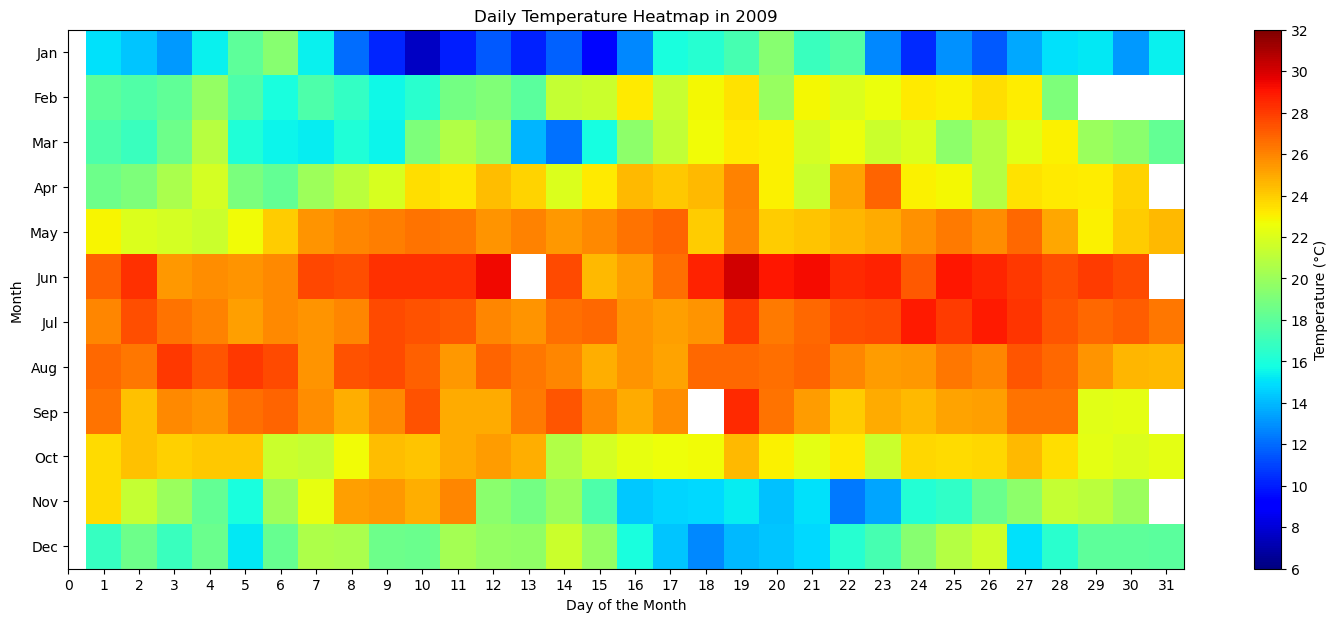

In [45]:
x_axis = np.arange(1,32,1)
y_axis = np.arange(1,13,1)
data=df.T[::-1]
x_axis, y_axis = np.meshgrid(x_axis, y_axis)
plt.figure(figsize=(18,7))
cm=plt.pcolormesh(x_axis,y_axis,data,cmap='jet',vmin=6,vmax=32)
bar=plt.colorbar(cm)
bar.set_label('Temperature (°C)')
bar.set_ticks(range(6,33,2))  
bar.set_ticklabels(range(6,33,2))
plt.xticks(range(32),range(32))
plt.yticks(range(12,0,-1), months)
plt.xlabel('Day of the Month')
plt.ylabel('Month')
plt.title("Daily Temperature Heatmap in 2009")
plt.subplots_adjust( wspace = 0.2)
plt.show()

# ex3

In [46]:
from mpl_toolkits.basemap import Basemap

/home/hungday/anaconda3/envs/dataVis/lib/python3.11/site-packages/pyproj/__init__.py:89: UserWarning: pyproj unable to set database path.
  _pyproj_global_context_initialize()


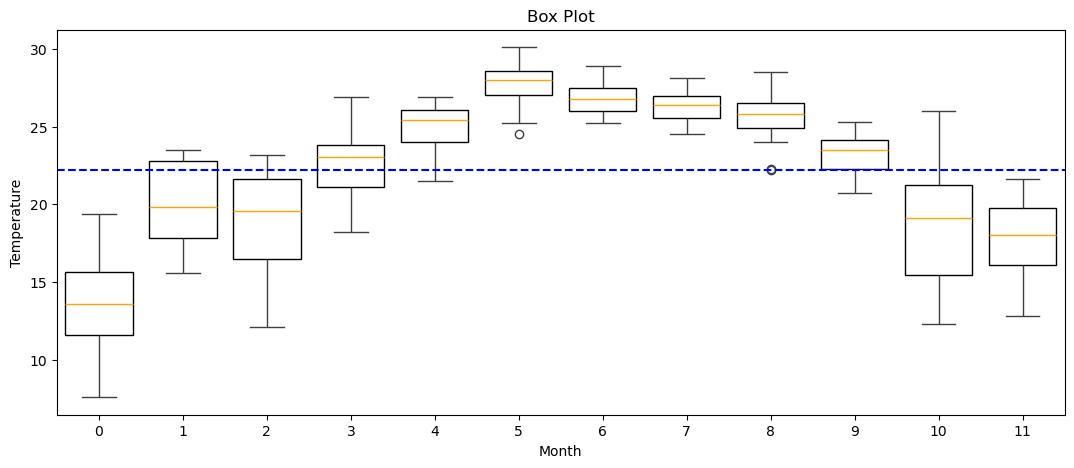

In [47]:
import seaborn as sns
# Reshape the DataFrame to long format
df_melted = pd.melt(df, var_name='Month', value_name='Value')
plt.figure(figsize=(13,5))
overall_mean = df_melted['Value'].mean()

# Plot the overall mean as a horizontal line

# Create the box plot using seaborn
sns.boxplot(x='Month', y='Value', data=df_melted,
            meanline=True, meanprops={'color': 'orange', 'linestyle': '-'},
            boxprops={'facecolor': 'white', 'edgecolor': 'black'},
            medianprops={'color': 'orange'})
plt.axhline(y=overall_mean, color='b', linestyle='--', label='Overall Mean')

# Customize the plot
plt.xlabel('month')
plt.ylabel('temperature')
plt.title('Box Plot')
plt.xlabel('Month')
plt.ylabel('Temperature')

# Show the plot
plt.show()

# ex4

In [48]:

from matplotlib.patches import Polygon
from numpy import *
from netCDF4 import * 
from datetime import *
import matplotlib.pyplot as plt
nc_path='/home/hungday/Documents/python/Data-visualization-/wrfout_d02_2019-11-12_sample.nc'
nc_file=Dataset(nc_path,'r')

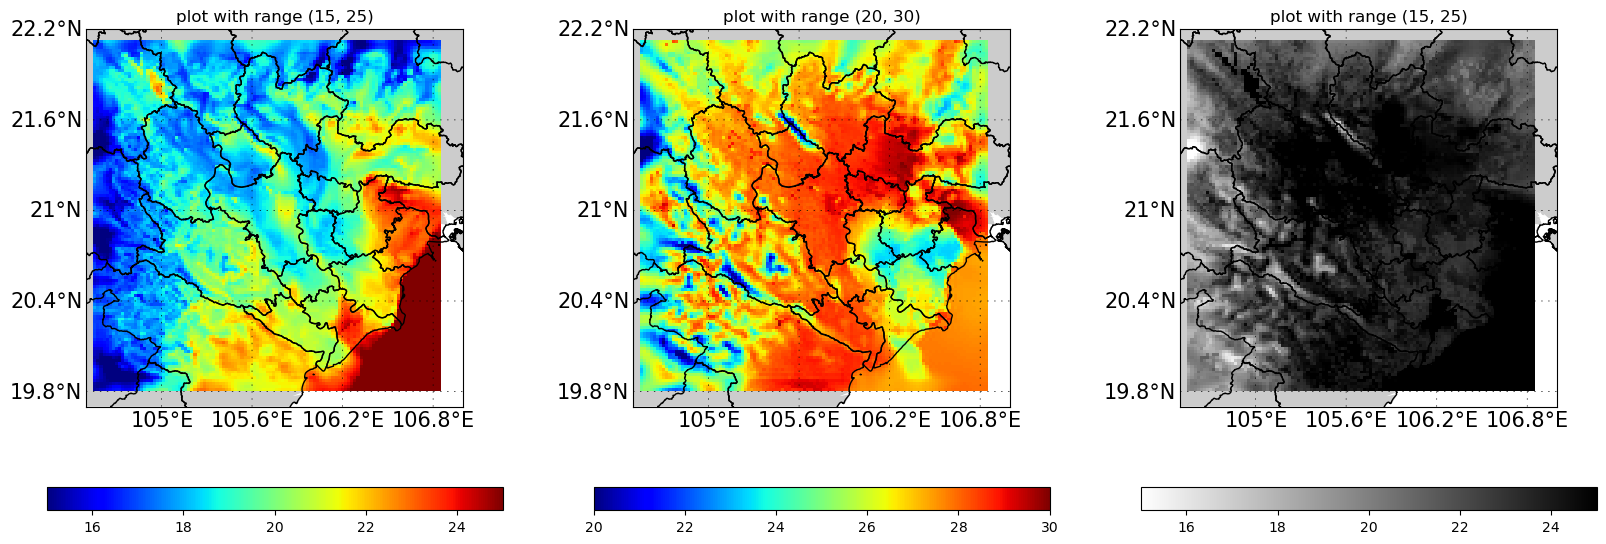

In [49]:
data=squeeze(nc_file.variables['T2'][:])
lat=squeeze(nc_file.variables['XLAT'][:])
lon=squeeze(nc_file.variables['XLONG'][:])
fig=plt.figure(figsize=(20,7))
lon_min=104.5
lon_max=107
lat_min=19.7
lat_max=22.2
vrange=[(15,25),(20,30),(15,25)]
for i in range(3):
    ax = plt.subplot(1,3, i+1)
    map2 = Basemap(projection='merc',
                  llcrnrlon=lon_min, #lower left corner longtitude
                  llcrnrlat=lat_min, #lower left corner lattitude
                  urcrnrlon=lon_max, #upper right corner longtitude
                  urcrnrlat=lat_max, #upper right corner lattitude
                  resolution='i',epsg=4326)
    map2.fillcontinents(zorder=0)
    parallels = arange(-90.,150., around((lat_max-lat_min)/4, decimals=1)) 	#lat
    meridians = arange(0.,180., around((lat_max-lat_min)/4, decimals=1))
    map2.drawparallels(parallels,linewidth=0.5,dashes=[2,8],labels=[1,0,0,0],fontsize=15, zorder=12) # left, right, top or bottom
    map2.drawmeridians(meridians,linewidth=0.5,dashes=[2,8],labels=[0,0,0,1],fontsize=15, zorder=12)
    #add vietName
    map2.readshapefile(r'gadm41_VNM_0/gadm41_VNM_1', "gadm41_VNM_1", linewidth=1,color='k')
    
    #plot data
    hour=i*6
    if i==2:
        cm = plt.pcolormesh( lon , lat , data[hour,:,:]-273.15,vmin = vrange[i][0],vmax = vrange[i][1],cmap='binary')
    else:
        cm = plt.pcolormesh( lon , lat , data[hour,:,:]-273.15,vmin = vrange[i][0],vmax = vrange[i][1],cmap='jet')
    plt.title(f"plot at {hour} hour")
    fig.colorbar(cm,orientation='horizontal')
    plt.title(f"plot with range {vrange[i]}")
    
plt.show()

# ex5

In [51]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
from datetime import *
from netCDF4 import *
import cartopy.crs as ccrs
import cartopy.feature as cfeatureplt
from cartopy.util import add_cyclic_point
import scipy.stats as stats

In [52]:
data=xr.open_dataset("sst.nc")

def calculate_nino34(data):    
    sst_nino34=data.sst.sel(lat=slice(-5,5),lon=slice(190,240))
    tmp=sst_nino34.groupby('time.month')
    tmp1=tmp-tmp.mean(dim="time")
    index_nino34=tmp1.mean(dim=["lat","lon"])
    return index_nino34

index_nino34 = calculate_nino34(data)

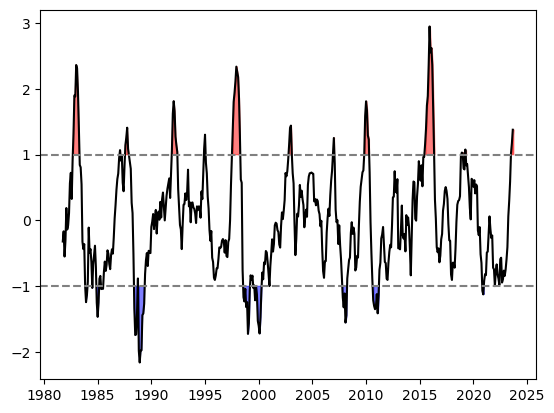

In [53]:
plt.plot(index_nino34, 'k')
# Draw the dashed horizontal line at y=1 and y=-1
plt.axhline(y=1, color='gray', linestyle='--')
plt.axhline(y=-1, color='gray', linestyle='--')
# Fill color
plt.fill_between(np.linspace(0,504,504),index_nino34, 1, where=(index_nino34 > 1), color='red', alpha=0.5)
plt.fill_between(np.linspace(0,504,504),index_nino34, -1, where=(index_nino34 < -1), color='blue', alpha=0.5)

# Year | start at sep 1981 and end at august 2023
x_ticks = np.arange(-21, 520, 5*12)
plt.xticks(x_ticks, [f"{1980 + i}" for i in range(0,46,5)])
plt.show()